In [ ]:
"""
Pertemuan 7: Clustering (K-Means & Hierarchical)
================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [2]:
# ============================================================
# 1. Contoh Dasar: K-Means & Hierarchical
# ============================================================
print("=" * 60)
print("Contoh: K-Means & Hierarchical")
print("=" * 60)

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

kmeans = KMeans(n_clusters=4, random_state=42)
labels_k = kmeans.fit_predict(X)

print("Inertia:", round(kmeans.inertia_, 2))
print("Silhouette K-Means:", round(silhouette_score(X, labels_k), 3))

agg = AgglomerativeClustering(n_clusters=4)
labels_h = agg.fit_predict(X)
print("Silhouette Hierarchical:", round(silhouette_score(X, labels_h), 3))

Contoh: K-Means & Hierarchical
Inertia: 564.91
Silhouette K-Means: 0.792
Silhouette Hierarchical: 0.792



Menentukan K Optimal
K= 2 → Inertia:   9416.2 | Silhouette: 0.590
K= 3 → Inertia:   2110.4 | Silhouette: 0.757
K= 4 → Inertia:    564.9 | Silhouette: 0.792
K= 5 → Inertia:    513.0 | Silhouette: 0.664
K= 6 → Inertia:    462.1 | Silhouette: 0.533
K= 7 → Inertia:    411.3 | Silhouette: 0.426
K= 8 → Inertia:    365.4 | Silhouette: 0.335
K= 9 → Inertia:    332.0 | Silhouette: 0.345
K=10 → Inertia:    291.6 | Silhouette: 0.362

K optimal berdasarkan silhouette tertinggi: K=4


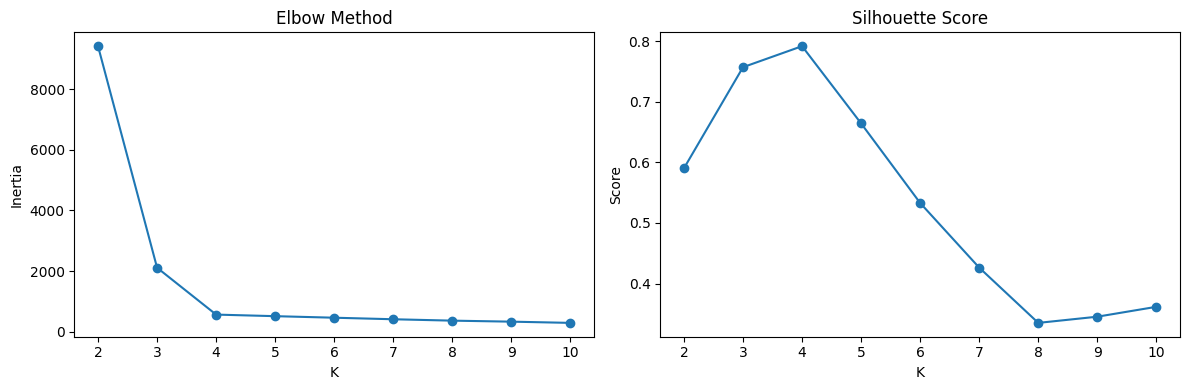

In [3]:
# ============================================================
# 2. Menentukan K Optimal (Elbow + Silhouette)
# ============================================================
print("\n" + "=" * 60)
print("Menentukan K Optimal")
print("=" * 60)

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    print(f"K={k:2d} → Inertia: {km.inertia_:8.1f} | Silhouette: {silhouette_score(X, labels):.3f}")

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\nK optimal berdasarkan silhouette tertinggi: K={best_k}")

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(list(K_range), inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(list(K_range), silhouettes, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 3. TUGAS: Segmentasi Pelanggan (Sintetis)
# ============================================================
print("\n" + "=" * 60)
print("Tugas: Segmentasi Pelanggan")
print("=" * 60)

np.random.seed(42)
income = np.concatenate([
    np.random.normal(30, 5, 50),
    np.random.normal(30, 5, 50),
    np.random.normal(70, 8, 50),
    np.random.normal(70, 8, 50),
])

spending = np.concatenate([
    np.random.normal(20, 5, 50),
    np.random.normal(70, 5, 50),
    np.random.normal(20, 5, 50),
    np.random.normal(70, 5, 50),
])

X_cust = np.column_stack([income, spending])

# Clustering
km_cust = KMeans(n_clusters=4, random_state=42)
labels_cust = km_cust.fit_predict(X_cust)



Tugas: Segmentasi Pelanggan


In [5]:
# ============================================================
# 4. Profil Cluster
# ============================================================
print("\nProfil Cluster:")
print(f"{'Cluster':>8}  {'Avg Income':>12}  {'Avg Spending':>13}  {'Count':>6}")

cluster_names = {}

for c in sorted(set(labels_cust)):
    mask = labels_cust == c
    avg_inc = income[mask].mean()
    avg_sp = spending[mask].mean()
    count = mask.sum()

    print(f"{c:>8d}  {avg_inc:12.1f}  {avg_sp:13.1f}  {count:6d}")

    # Pemberian nama segmen
    if avg_inc > 50 and avg_sp > 50:
        name = "High Value (Premium)"
    elif avg_inc > 50 and avg_sp <= 50:
        name = "Potential Saver"
    elif avg_inc <= 50 and avg_sp > 50:
        name = "High Spender"
    else:
        name = "Budget Customer"

    cluster_names[c] = name


Profil Cluster:
 Cluster    Avg Income   Avg Spending   Count
       0          30.1           69.9      50
       1          70.7           70.9      50
       2          28.9           20.8      50
       3          69.7           20.2      50


In [6]:
# ============================================================
# 5. Nama Segmen
# ============================================================
print("\nNama Segmen:")
for c, name in cluster_names.items():
    print(f"Cluster {c}: {name}")



Nama Segmen:
Cluster 0: High Spender
Cluster 1: High Value (Premium)
Cluster 2: Budget Customer
Cluster 3: Potential Saver


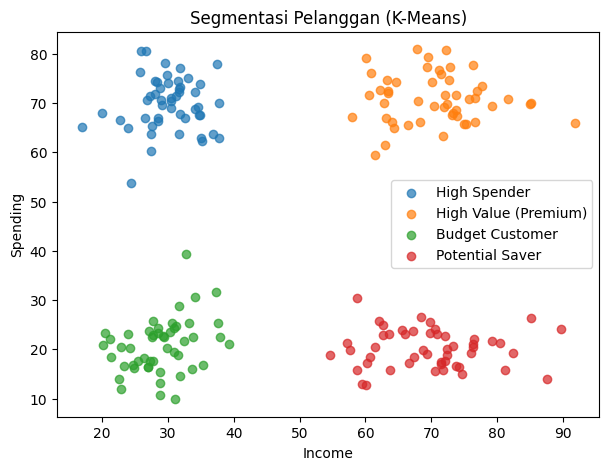

In [7]:
# ============================================================
# 6. Visualisasi Segmentasi
# ============================================================
plt.figure(figsize=(7,5))
for c in sorted(set(labels_cust)):
    mask = labels_cust == c
    plt.scatter(income[mask], spending[mask], label=cluster_names[c], alpha=0.7)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Segmentasi Pelanggan (K-Means)")
plt.legend()
plt.show()

In [8]:
# ============================================================
# 7. Rekomendasi Bisnis
# ============================================================
print("\n" + "=" * 60)
print("3 Rekomendasi Bisnis")
print("=" * 60)

print("1. Segmen High Value (Premium): berikan loyalty program, cashback,")
print("   dan produk eksklusif untuk mempertahankan nilai transaksi tinggi.")

print("2. Segmen Potential Saver: tawarkan promo personalisasi untuk")
print("   meningkatkan frekuensi pembelian.")

print("3. Segmen Budget Customer: fokus pada diskon dan produk ekonomis")
print("   agar tetap loyal meskipun daya beli terbatas.")

print("\n✅ Pertemuan 07 selesai.")


3 Rekomendasi Bisnis
1. Segmen High Value (Premium): berikan loyalty program, cashback,
   dan produk eksklusif untuk mempertahankan nilai transaksi tinggi.
2. Segmen Potential Saver: tawarkan promo personalisasi untuk
   meningkatkan frekuensi pembelian.
3. Segmen Budget Customer: fokus pada diskon dan produk ekonomis
   agar tetap loyal meskipun daya beli terbatas.

✅ Pertemuan 07 selesai.
